# QSO redshift-error smearing before multipole projection

This notebook is a model-independent example for the DESI DR2 QSO mock challenge. It uses:

- `redshift_error_window.py`: portable NumPy/JAX implementation;
- `PDF_smearing_QSO_z0.8-2.1_dv-kms.npz`: measured line-of-sight velocity-error PDF for $0.8<z<2.1$;
- optionally, the exported mock-challenge HDF5 file to read the exact QSO effective redshift.

The correction acts on the **full anisotropic prediction before angular projection**. Do not apply it directly to already projected $P_\ell$ or $B_{\ell_1\ell_2L}$ arrays.


## 1. Model and operation order

Let $q=k_\parallel=k\mu$, evaluated in the observed/fiducial coordinates used to measure the data. The measured velocity-error PDF gives the single-field characteristic function

$$
D_{\rm PDF}(q)=\int d(\Delta v)\,p(\Delta v)\cos\!\left(\frac{q\,\Delta v}{aH_{\rm fid}}\right),
$$

where

$$
aH_{\rm fid}=\frac{100\,E_{\rm fid}(z_{\rm eff})}{1+z_{\rm eff}}
$$

is in km s$^{-1}$ per Mpc/$h$. The residual Gaussian contribution is

$$
D_{\rm G}(q;v_{\rm smear})=\exp\left[-\frac{1}{2}(qv_{\rm smear})^2\right],
$$

so $D_{\rm tot}=D_{\rm PDF}D_{\rm G}$. The anisotropic predictions are modified as

$$
P^{\rm smear}(k,\mu)=D_{\rm tot}(k\mu)^2P^{\rm full}(k,\mu),
$$

and

$$
B^{\rm smear}=D_{\rm tot}(q_1)D_{\rm tot}(q_2)D_{\rm tot}(q_3)B^{\rm full}.
$$

The required order is: full anisotropic theory $\rightarrow$ redshift smearing $\rightarrow$ multipole projection $\rightarrow$ exported survey window $\rightarrow$ $\chi^2$.


In [1]:
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

from redshift_error_window import make_windows, tabulate_pdf_damping

PDF_FILE = Path("PDF_smearing_QSO_z0.8-2.1_dv-kms.npz")
EXPORT_FILE = Path(
    "desi_inputs_all_tracers_holi_v3_altmtl_qso_single_lorentzian.h5"
)

QMAX = 1.0       # h/Mpc; must exceed every absolute k_parallel used below
NQ = 2049        # tabulation points for D_PDF(q)
VSMEAR_EXAMPLE = 2.0  # Mpc/h; only an illustration
VSMEAR_PRIOR = (0.0, 50.0)  # flat bounds proposed in the accompanying message
Z_EFF_FALLBACK = 1.48
A_H_FID_OVERRIDE = None  # set a positive number here if cosmoprimo is unavailable

if not PDF_FILE.is_file():
    raise FileNotFoundError(
        f"Could not find {PDF_FILE}. Put the PDF beside this notebook."
    )

# Prefer the exact effective redshift stored with the exported QSO data.
if EXPORT_FILE.is_file():
    import h5py

    with h5py.File(EXPORT_FILE, "r") as h5:
        z_eff = float(h5["tracers/QSO1/metadata/zeff"][()])
    z_source = f"{EXPORT_FILE}: /tracers/QSO1/metadata/zeff"
else:
    z_eff = Z_EFF_FALLBACK
    z_source = "documented fallback; replace with the exact QSO window zeff"

# aH_fid is fixed by the fiducial coordinate conversion; it is not varied
# with the sampled cosmology. The DESI environment provides cosmoprimo,
# while other pipelines may supply the same fiducial value explicitly.
if A_H_FID_OVERRIDE is None:
    try:
        from cosmoprimo.fiducial import DESI
    except ModuleNotFoundError as exc:
        raise ModuleNotFoundError(
            "Install cosmoprimo or set A_H_FID_OVERRIDE to the value from "
            "the fiducial cosmology used to convert the catalogue coordinates."
        ) from exc
    aH_fid = 100.0 * DESI().efunc(z_eff) / (1.0 + z_eff)
else:
    aH_fid = float(A_H_FID_OVERRIDE)

if not np.isfinite(aH_fid) or aH_fid <= 0.0:
    raise ValueError("aH_fid must be finite and positive.")

print(f"z_eff  = {z_eff:.8f} ({z_source})")
print(f"aH_fid = {aH_fid:.8f} km/s per Mpc/h")


z_eff  = 1.48494796 (desi_inputs_all_tracers_holi_v3_altmtl_qso_single_lorentzian.h5: /tracers/QSO1/metadata/zeff)
aH_fid = 94.58414510 km/s per Mpc/h


## 2. Inspect the supplied PDF

This is a diagnostic only. `make_windows` normalises the PDF internally using trapezoidal weights, including for a non-uniform velocity grid.


redshift range = [0.8 2.1]
dv unit        = km/s
PDF integral   = 1.0000006432
median dv      = -0.047468 km/s


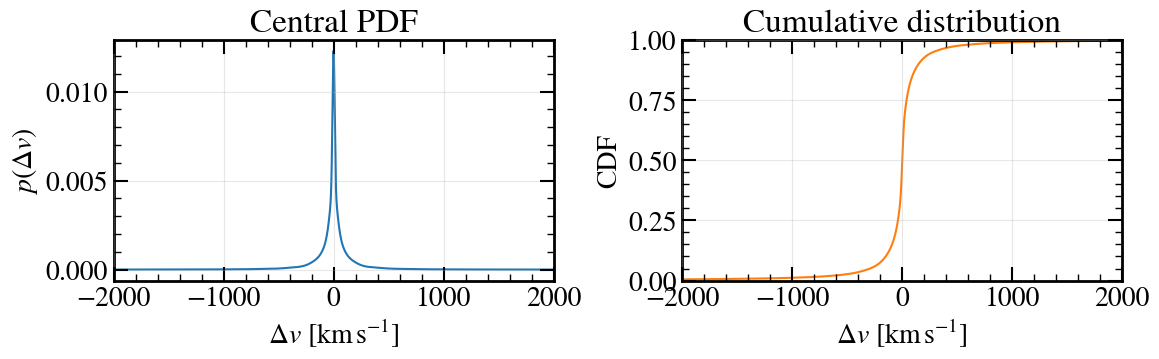

In [2]:
with np.load(PDF_FILE, allow_pickle=False) as pdf_data:
    dv = np.asarray(pdf_data["dv"], dtype=float)
    pdf = np.asarray(pdf_data["pdf"], dtype=float)
    cdf = np.asarray(pdf_data["cdf"], dtype=float)
    dv_unit = str(pdf_data["dv_unit"].item())
    redshift_range = np.asarray(pdf_data["redshift_range"], dtype=float)

normalisation = np.trapezoid(pdf, dv)
print("redshift range =", redshift_range)
print("dv unit        =", dv_unit)
print(f"PDF integral   = {normalisation:.10f}")
print(f"median dv      = {np.interp(0.5, cdf, dv):.6f} km/s")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(dv, pdf, color="C0")
axes[0].set_xlim(-2000.0, 2000.0)
axes[0].set_xlabel(r"$\Delta v\ [{\rm km\,s^{-1}}]$")
axes[0].set_ylabel(r"$p(\Delta v)$")
axes[0].set_title("Central PDF")
axes[0].grid(alpha=0.3)

axes[1].plot(dv, cdf, color="C1")
axes[1].set_xlim(-2000.0, 2000.0)
axes[1].set_ylim(0.0, 1.0)
axes[1].set_xlabel(r"$\Delta v\ [{\rm km\,s^{-1}}]$")
axes[1].set_ylabel("CDF")
axes[1].set_title("Cumulative distribution")
axes[1].grid(alpha=0.3)
plt.tight_layout()
plt.show()


## 3. Construct the reusable operators

Construct these once, outside the likelihood evaluation loop. Use `backend="jax"` in a JAX sampler and keep `vsmear` as a dynamic argument. NumPy is used here so the demonstration remains easy to inspect.


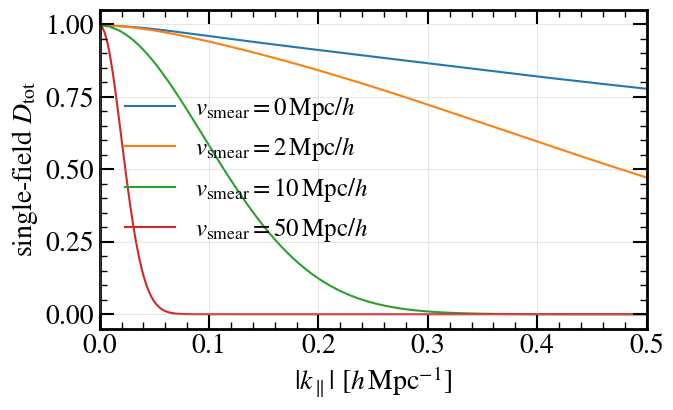

In [3]:
pk_window, bk_window = make_windows(
    PDF_FILE,
    aH_fid,
    qmax=QMAX,
    nq=NQ,
    backend="numpy",  # change to 'jax' in a JAX likelihood
)

q_grid, d_pdf = tabulate_pdf_damping(
    PDF_FILE, aH_fid, qmax=QMAX, nq=NQ
)

fig, ax = plt.subplots(figsize=(7, 4.5))
for vsmear in [0.0, 2.0, 10.0, 50.0]:
    d_total = d_pdf * np.exp(-0.5 * (q_grid * vsmear) ** 2)
    ax.plot(q_grid, d_total, label=fr"$v_{{\rm smear}}={vsmear:g}\,{{\rm Mpc}}/h$")
ax.set_xlim(0.0, min(QMAX, 0.5))
ax.set_xlabel(r"$|k_\parallel|\ [h\,{\rm Mpc}^{-1}]$")
ax.set_ylabel(r"single-field $D_{\rm tot}$")
ax.grid(alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()


## 4. Power-spectrum example

The following toy Kaiser spectrum demonstrates the required placement of `pk_window`. Replace `pk_full` with the complete anisotropic prediction from your model.


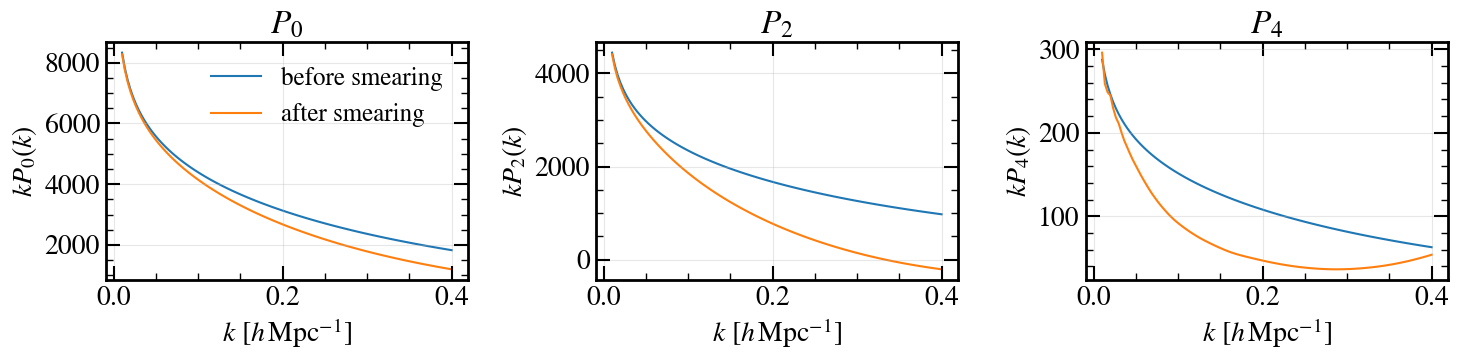

In [4]:
def legendre_polynomial(ell, mu):
    coefficients = np.zeros(ell + 1)
    coefficients[ell] = 1.0
    return np.polynomial.legendre.legval(mu, coefficients)


def project_power_multipoles(pk_mu, mu, weights, ells=(0, 2, 4)):
    """Project an array shaped (Nk, Nmu) onto Legendre multipoles."""
    return {
        ell: (2 * ell + 1) / 2.0
        * np.sum(pk_mu * legendre_polynomial(ell, mu)[None, :]
                 * weights[None, :], axis=1)
        for ell in ells
    }


k = np.linspace(0.01, 0.40, 120)
mu, mu_weights = np.polynomial.legendre.leggauss(128)
q_parallel = k[:, None] * mu[None, :]

if np.max(np.abs(q_parallel)) > QMAX:
    raise ValueError("Increase QMAX: the power angular grid exceeds the damping table.")

# Toy full anisotropic model; use the complete model prediction here.
b1, growth = 2.0, 0.9
p_matter = 1.0e4 * (k / 0.1) ** (-1.2) * np.exp(-2.0 * k)
pk_full = (b1 + growth * mu[None, :] ** 2) ** 2 * p_matter[:, None]

pk_smeared = pk_window(pk_full, q_parallel, VSMEAR_EXAMPLE)
pell_full = project_power_multipoles(pk_full, mu, mu_weights)
pell_smeared = project_power_multipoles(pk_smeared, mu, mu_weights)

fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharex=True)
for ax, ell in zip(axes, (0, 2, 4)):
    ax.plot(k, k * pell_full[ell], label="before smearing")
    ax.plot(k, k * pell_smeared[ell], label="after smearing")
    ax.set_title(fr"$P_{{{ell}}}$")
    ax.set_xlabel(r"$k\ [h\,{\rm Mpc}^{-1}]$")
    ax.set_ylabel(fr"$kP_{{{ell}}}(k)$")
    ax.grid(alpha=0.3)
axes[0].legend()
plt.tight_layout()
plt.show()


## 5. Bispectrum example

For every orientation of a closed triangle, pass the three fiducial line-of-sight components $q_i=k_i\mu_i$. Closure implies $q_1+q_2+q_3=0$. Apply `bk_window` to the full orientation-dependent bispectrum and only then perform the Sugiyama angular projection.


In [5]:
# A few illustrative triangle orientations. Real pipelines will have
# multidimensional arrays over triangle size and angular quadrature.
q1 = np.array([0.05, 0.10, 0.20])
q2 = np.array([-0.02, -0.04, -0.08])
q3 = -(q1 + q2)

np.testing.assert_allclose(q1 + q2 + q3, 0.0, atol=1e-14)
if max(np.max(np.abs(q1)), np.max(np.abs(q2)), np.max(np.abs(q3))) > QMAX:
    raise ValueError("Increase QMAX: the bispectrum angular grid exceeds the damping table.")

bk_full = np.full_like(q1, 1.0e8)
bk_smeared = bk_window(bk_full, q1, q2, q3, VSMEAR_EXAMPLE)

print(" q1       q2       q3       B_smeared / B_full")
for values in zip(q1, q2, q3, bk_smeared / bk_full):
    print(f"{values[0]:7.3f}  {values[1]:7.3f}  {values[2]:7.3f}  {values[3]:18.8f}")

# Sanity check: for (q, -q, 0), the B and P damping factors are equal.
q_test = np.array([0.0, 0.1, 0.2])
unit = np.ones_like(q_test)
p_damping = pk_window(unit, q_test, VSMEAR_EXAMPLE)
b_damping = bk_window(unit, q_test, -q_test, np.zeros_like(q_test), VSMEAR_EXAMPLE)
np.testing.assert_allclose(p_damping, b_damping, rtol=1e-12, atol=1e-12)
print("Sanity check P(q) = B(q, -q, 0): passed")


 q1       q2       q3       B_smeared / B_full
  0.050   -0.020   -0.030          0.96300827
  0.100   -0.040   -0.060          0.90151366
  0.200   -0.080   -0.120          0.74420046
Sanity check P(q) = B(q, -q, 0): passed


## 6. Likelihood integration

Construct the operators once and evaluate them inside the model with the sampled `vsmear`:

```python
pk_window, bk_window = make_windows(PDF_FILE, aH_fid, backend="jax")

def predict(parameters):
    vsmear = parameters["vsmear"]  # Mpc/h

    pk_full, k_parallel = model.full_anisotropic_power(parameters)
    pk_smeared = pk_window(pk_full, k_parallel, vsmear)
    power_multipoles = model.project_power(pk_smeared)

    bk_full, q1, q2, q3 = model.full_anisotropic_bispectrum(parameters)
    bk_smeared = bk_window(bk_full, q1, q2, q3, vsmear)
    bispectrum_multipoles = model.project_bispectrum(bk_smeared)

    return power_multipoles, bispectrum_multipoles
```

The helper imposes no prior. The accompanying modelling guidance proposes

$$
v_{\rm smear}\sim\mathcal{U}(0,50)\ {\rm Mpc}/h.
$$

Set this in the sampler itself. If the mock-challenge prior is revised, change the sampler configuration; the smearing functions do not need to change.



## 7. Conventions and double-counting checks

- Use fiducial/observed $k_\parallel$ **before AP rescaling**.
- Keep `aH_fid` fixed to the fiducial cosmology used to construct the catalogue coordinates.
- Apply the damping to the complete anisotropic model before multipole projection.
- Ensure `QMAX >= max(abs(k_parallel))` over every power and bispectrum angular node. Values outside the table deliberately return `NaN`.
- The measured PDF and residual Gaussian are both single-field factors: two factors enter $P$ and three enter $B$.
- Do **not** also use a survey window into which the same measured PDF has already been folded. That would apply $D_{\rm PDF}$ twice.

The `desi-clustering` function `window_with_redshift_smearing` implements an alternative but related route: it projects the measured-PDF damping into a multipole-mixing matrix $M$ and composes the survey window as $W'=WM$. The portable functions used here instead apply the damping directly to the full anisotropic prediction. Choose one route for the measured PDF, not both.
